# Machine Learning: Volatility Forecasting

## Introduction
prob, sol, methods, imple

### Imports

In [1]:
import src.paths as paths
import src.volatility as volatility
import src.machine_learning as ml
import src.feature_engineering as fe
from src.data import load_data
import run_updates

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

import importlib
importlib.reload(ml)

<module 'src.machine_learning' from 'c:\\Users\\jspit\\OneDrive\\Documents\\personal projects\\Machine Learning Fin\\src\\machine_learning.py'>

# Data

Daily OHLCV data is obtained from yfinance and FRED, and is used to construct the volatility target and endogenous features. VIX is incorporated as an exogneous measure of overall market volatility.

The analysis uses BTC.

Data is loaded through the project's data pipeline which handles retrieval, caching, cleaning, and alignment.

Run this first to fetch the latest stock/market data.

In [2]:
run_updates.main()

Loaded and processed: commodities (10 items)
Loaded and processed: crypto (29 items)
Loaded and processed: macro (31 items)
Loaded and processed: equities (15 items)
Loaded and processed: forex (6 items)
Loaded and processed: indices (24 items)
Starting update run...

[commodities]
completed: 10 updated, 0 skipped, 0 failed
saved rows=6723 cols=50 range=2000-01-03 to 2026-09-09

[crypto]
completed: 29 updated, 0 skipped, 0 failed
saved rows=4376 cols=145 range=2014-09-17 to 2026-09-09

[macro]
Unsupported source: Scrape
completed: 30 updated, 1 skipped, 0 failed
saved rows=17688 cols=34 range=1913-01-01 to 2026-09-09

[equities]
completed: 15 updated, 0 skipped, 0 failed
saved rows=16279 cols=75 range=1962-01-02 to 2026-09-08

[forex]
completed: 6 updated, 0 skipped, 0 failed
saved rows=14141 cols=30 range=1971-01-04 to 2026-09-09

[indices]
completed: 24 updated, 0 skipped, 0 failed
saved rows=25307 cols=120 range=1927-12-30 to 2026-09-09

Run complete
updated=114 skipped=1 failed=0
l

Load the data to be used in the analysis

In [3]:
asset = 'BTC'

ohlcv = load_data(paths.CRYPTO_DATA_PARQUET, '1d')
asset_ohlcv = ohlcv[asset].dropna()

asset_ohlcv.name = asset

asset_ohlcv.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-09-05,79823.867188,80194.507812,79465.062500,79671.703125,1.855971e+10
2026-09-06,80350.046875,80530.648438,79327.500000,79824.601562,1.939186e+10
2026-09-07,79115.851562,80432.312500,78684.929688,80349.195312,2.341443e+10
2026-09-08,78438.578125,79463.273438,77635.687500,79114.906250,3.468017e+10
2026-09-09,79082.171875,79691.656250,78446.179688,78446.179688,2.756411e+10


# Volatility Measure

Parkinson Volatility is used to estimate the daily volatility. This measure uses daily high and low prices to incorporate information about intraday variation, providing a better estimate than Realised Absolute Volume which only uses close-to-close prices. Parkinson volatility is a good estimate for 24/7 markets, however it does not account for overnight volatility and price jumps - a weakness when it comes to typical stock market data. To address this, the Yang-Zhang volatility estimator could be implemented for stock market data.

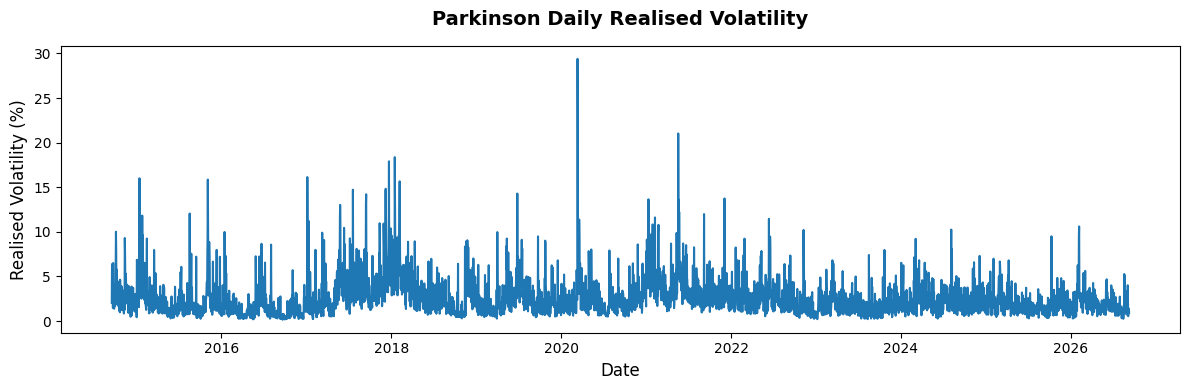

In [4]:
realised_vol = volatility.parkinson_vol(asset_ohlcv)

plt.figure(figsize=(12, 4)) 
plt.plot(realised_vol)
plt.title('Parkinson Daily Realised Volatility', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Realised Volatility (%)', fontsize=12)
plt.tight_layout()
plt.show()


# Volatility Forecast Benchmarks

### GARCH(1,1)
Statistical formula used to forecast time-varying volatility that combines the long-term baseline, recent market shocks and past volatility. Taken over 500-day rolling window (i.e. use T-500 to predict T).

### Naive Persistent
Simplest possible forecast, predicts tomorrow's volatility as today's value.

### Naive Rolling Average
Smooths the variance of the Naive Persistent forecast, accounts for previous short-term history and shocks.

In [5]:
garch_forecast = volatility.garch_forecast(asset_ohlcv['Close'], 500)
naive_persistent_forecast = volatility.naive_persistent_forecast(realised_vol)
naive_rolling_avg_forecast = volatility.naive_avg_forecast(realised_vol, 21)

benchmarks = {
    'GARCH(1,1)': garch_forecast,
    'Naive (persistence)': naive_persistent_forecast,
    'Naive (rolling avg)': naive_rolling_avg_forecast
}

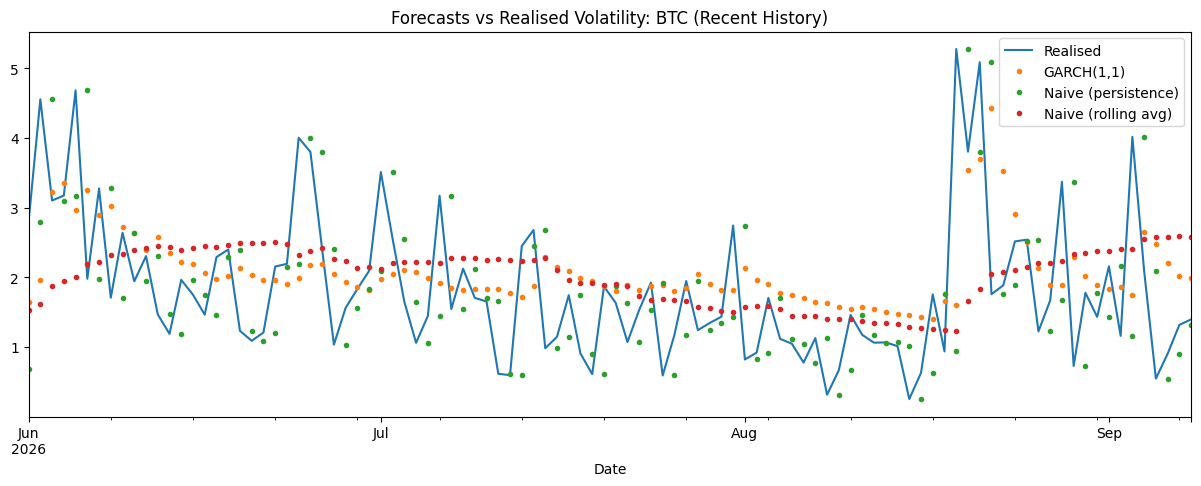

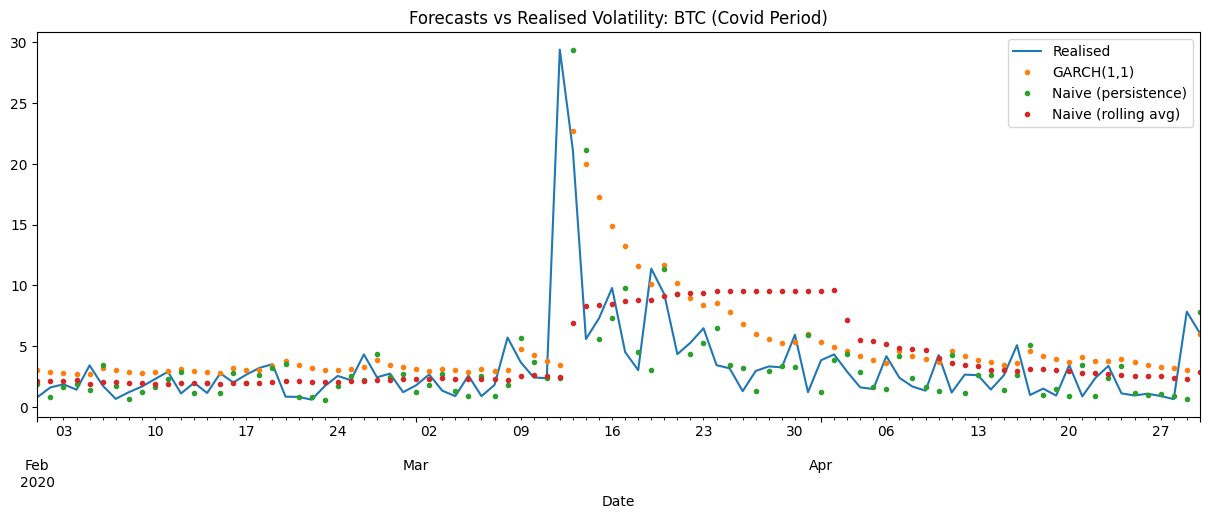

In [19]:
recent = ml.filter_forecasts(benchmarks, '2026-06-01', '2026-09-08')
covid = ml.filter_forecasts(benchmarks, '2020-02-01', '2020-04-30')

ml.plot_predictions_vs_realised(realised_vol, recent, f'{asset} (Recent History)')
ml.plot_predictions_vs_realised(realised_vol, covid, f'{asset} (Covid Period)')

Behaviour of GARCH clear:

Sensitive to volatility spikes, then decays towards baseline

# Feature Engineering

The model uses both endogenous and exogenous volatility information

### Volatility
Historic Parkinson volatility, including lags

### Returns
Historic asset returns, including lags

### Moving Averages
Simple and exponential moving averages of volatility and price

### Normalised Price
Price normalised by moving averages, price overextended in either direction relative to recent history

### Normalised Volume
Volume normalised by moving averages, volume overextended in either direction relative to recent history

### VIX
Including lags (exogenous feature, would make eg Monte Carlo sims difficult)

### Calendar
Including day of week, month, quarter etc

In [21]:
features = fe.build_ml_features(asset_ohlcv)

features.tail()

Price,Close,High,Low,Open,Volume,Parkinson,VIX_0,Realised_vol_0,Returns_0,VIX_1,...,Price_vs_sma21,Price_vs_sma50,Price_vs_sma200,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-05,79823.867188,80194.507812,79465.062500,79671.703125,1.855971e+10,0.548767,14.53,2.094834,-0.019881,14.32,...,1.062119,1.158422,1.144345,5,3,9,2026,248,5,36
2026-09-06,80350.046875,80530.648438,79327.500000,79824.601562,1.939186e+10,0.904024,14.53,0.548767,0.001905,14.53,...,1.052915,1.155281,1.145512,6,3,9,2026,249,6,36
2026-09-07,79115.851562,80432.312500,78684.929688,80349.195312,2.341443e+10,1.319093,14.53,0.904024,0.006570,14.53,...,1.048312,1.157685,1.151912,0,3,9,2026,250,7,37
2026-09-08,78438.578125,79463.273438,77635.687500,79114.906250,3.468017e+10,1.397370,15.30,1.319093,-0.015479,14.53,...,1.022925,1.135184,1.133231,1,3,9,2026,251,8,37
2026-09-09,79082.171875,79691.656250,78446.179688,78446.179688,2.756411e+10,0.946011,15.72,1.397370,-0.008597,15.30,...,1.005650,1.121216,1.122691,2,3,9,2026,252,9,37


In [22]:
features.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Parkinson', 'VIX_0',
       'Realised_vol_0', 'Returns_0', 'VIX_1', 'Realised_vol_1', 'Returns_1',
       'VIX_2', 'Realised_vol_2', 'Returns_2', 'VIX_5', 'Realised_vol_5',
       'Returns_5', 'VIX_10', 'Realised_vol_10', 'Returns_10', 'VIX_20',
       'Realised_vol_20', 'Returns_20', 'VIX_60', 'Realised_vol_60',
       'Returns_60', 'VIX_120', 'Realised_vol_120', 'Returns_120', 'Vol_7_sma',
       'Vol_7_ema', 'Price_7_sma', 'Price_7_ema', 'Normalised_Volume_sma7',
       'Normalised_Volume_ema7', 'Vol_14_sma', 'Vol_14_ema', 'Price_14_sma',
       'Price_14_ema', 'Normalised_Volume_sma14', 'Normalised_Volume_ema14',
       'Vol_21_sma', 'Vol_21_ema', 'Price_21_sma', 'Price_21_ema',
       'Normalised_Volume_sma21', 'Normalised_Volume_ema21', 'Vol_50_sma',
       'Vol_50_ema', 'Price_50_sma', 'Price_50_ema', 'Normalised_Volume_sma50',
       'Normalised_Volume_ema50', 'Vol_200_sma', 'Vol_200_ema',
       'Price_200_sma', 'Price_200_ema'

# XGBoost Model

### XGBoost
Allows unlimited external variables

Prevents overfitting

Captures non-linear relationships

Extremely efficient

### Initial Parameters
Most are chosen as their default value

| Parameter | Value | Rationale |
| :--- | :--- | :--- |
| **Base score** | 0.5 | Default start point |
| **Max depth** | 3 | Limit model complexity |
| **Learning rate** | 0.01 | Gradual boosting |
| **Min child weight** | 1 | Less aggressive pruning |
| **Estimators** | 1000 | Upper bound with early stopping |
| **Early stopping** | 50 | Prevent unnecessary iterations |

### Train/Test Split
As volatilty is a time series, the data is split by date (here arbitrarily chosen as 2024-01-01). The model is trained on the data before split_date and evaluated on its forecasts after split_date to avoid leakage. The training data is further split into "train" and "eval" 80:20 chronologically. The "eval" data is used by XGBoost to monitor its performance during training, alongside early stopping, to optimise boosting, prevent overfitting, and improve generalisability.

When model is trained can use feature importance to improve feature selection and feature ablation to measure the impact of features on the model.

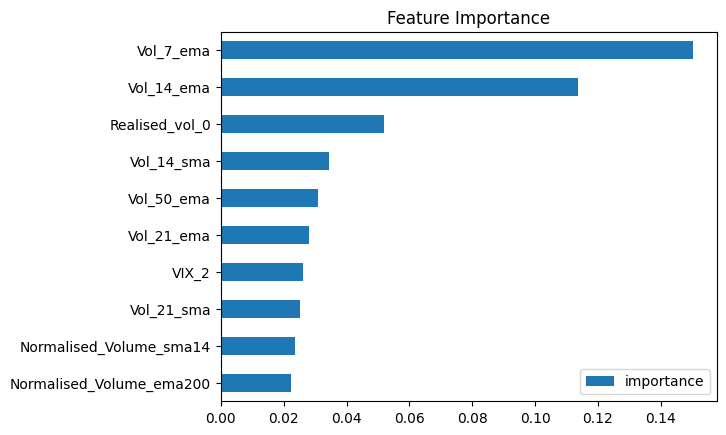

In [23]:
train_data, test_data = ml.split_train_test(features, split_date='2024-01-01')
model = ml.train_model(train_data)

ml.plot_feature_importance(model, 10)

# Forecasting
Use the trained model to make forecasts for future volatility. Here the volatility is forecasted from 2024-01-01 to present and compared against the actual realised volatility over that period

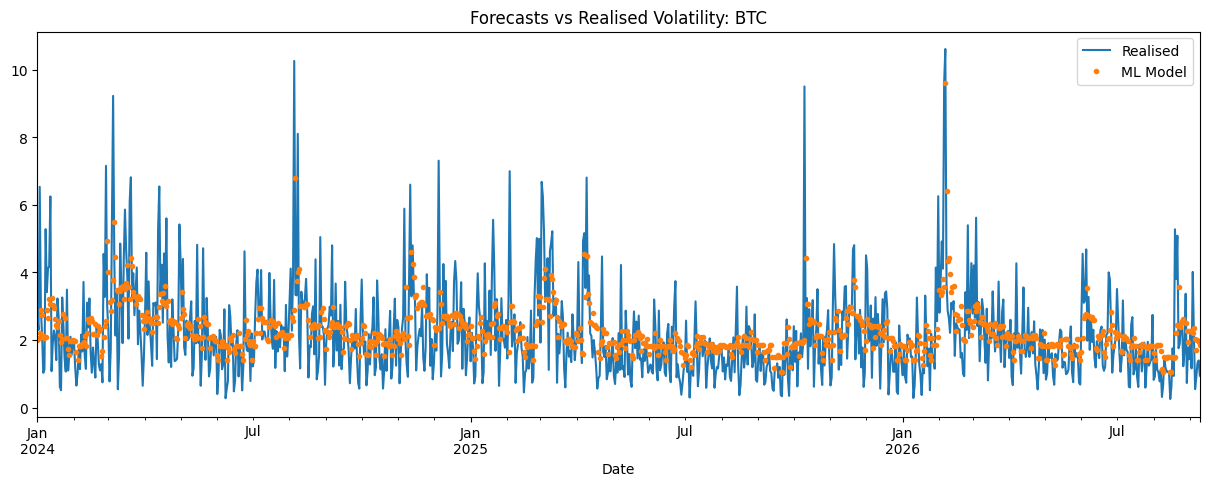

In [50]:
model_forecast = ml.forecast_model(test_data, model)

forecast = {'ML Model': model_forecast}

ml.plot_predictions_vs_realised(realised_vol, forecast, asset)

Model performance is evaluated using QLIKE, MSE, and MAE.

It is then compared with GARCH and the two naive forecasts. A lower relative loss performance signals a better model.

In [51]:
forecasts = {
    'GARCH(1,1)': garch_forecast,
    'Naive (persistence)': naive_persistent_forecast,
    'Naive (rolling avg)': naive_rolling_avg_forecast,
    'ML Model': model_forecast,
}

results = ml.compare_forecasts(forecasts, realised_vol)

df = pd.DataFrame(results).T.round(4)
print(df)

                      qlike       mse     mae
GARCH(1,1)           0.5794   91.6976  5.0719
Naive (persistence)  1.2760  135.6684  5.9995
Naive (rolling avg)  0.6373   99.9343  5.3489
ML Model             0.5021   78.6961  4.4180


# Walk-Forward Validation

The split date chosen previously was rather arbitrary. Could a different date have led to a better or worse model? Was the model trained on too little data to make good forecasts? Does the model forecast too far in the future such that it becomes stale and loses its predictive power?

To evaluate the model it must be validated.

k-fold or random sampling validations cannot be used with time series data (without introducing techniques such as purging) as this will lead to data leakage, where the model has access to the data it is predicting.

Instead the model is trained on an expanding window of data and then used to forecast the next window. This ensures the model is never trained on data which would not have been available to it at the time of prediction.

### Expanding Window
More data available to each subsequent model, better predictions can be made. Used in the following analysis.

train [-----] -> forecast [xxxxx]

train [----------] -> forecast [xxxxx]

train [---------------] -> forecast [xxxxx]

### Rolling Window
A similar implementation could use a rolling window. Easily adapts to different regimes.

train [-----] -> forecast [xxxxx-----]

[-----] train [-----] -> forecast [xxxxx]

[----------] train [-----] -> forecast [xxxxx]

In [54]:
results_per_block, results_combined, forecasts = ml.run_walk_forward_comparison(asset_ohlcv)

This walk forward returns:

results_per_block: qlike, mse, mae evaluated over each individual forecast window

results_combined: qlike, mse, mae evaluated as a concatenation of the forecast windows

forecasts: the full concatenated forecast

In [55]:
df = pd.DataFrame(results_combined).T.round(4)
print(df)

                          qlike       mse      mae
GARCH(1,1)               0.8019  676.1394  10.8708
Naive (persistence)      1.9157  836.2759  10.4468
Naive (rolling avg)      1.0046  740.6088  11.4939
ML Model (Walk-Forward)  0.8273  655.6160   8.6014


Model   GARCH(1,1)  ML Model  Naive (persistence)  Naive (rolling avg)
mean        0.8053    0.8289               1.9147               1.0064
std         0.3283    0.4882               1.2873               0.4292
median      0.6644    0.6532               1.4601               0.9033
min         0.3831    0.3007               0.6744               0.4055
max         1.5791    2.7174               6.6931               2.0424


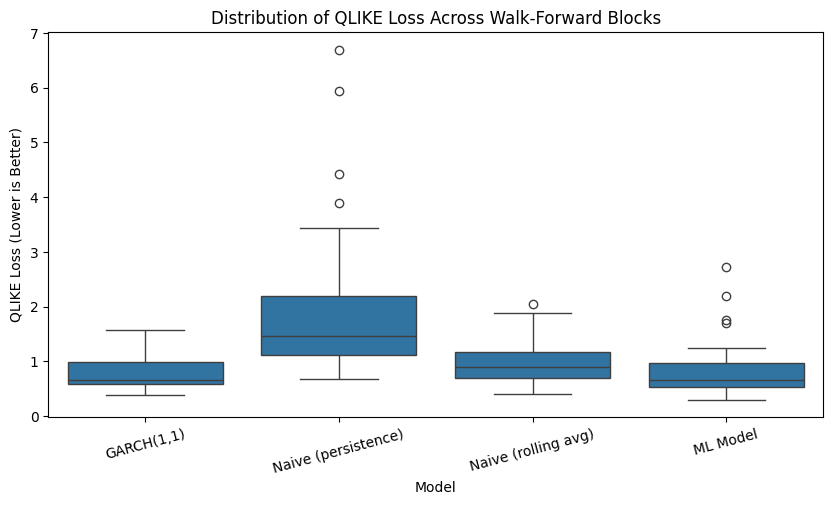

In [56]:
rows = []
for block, models in results_per_block.items():
    for model, metrics in models.items():
        row = {'Block': block, 'Model': model}
        row.update(metrics)
        rows.append(row)

df = pd.DataFrame(rows)

summary_stats = df.groupby('Model')[['qlike', 'mse', 'mae']].agg(['mean', 'std', 'median', 'min', 'max'])
summary_stats = summary_stats.round(4)

print(summary_stats['qlike'].T)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df.reset_index(), x='Model', y='qlike')
plt.title('Distribution of QLIKE Loss Across Walk-Forward Blocks')
plt.ylabel('QLIKE Loss (Lower is Better)')
plt.xticks(rotation=15)
plt.show()


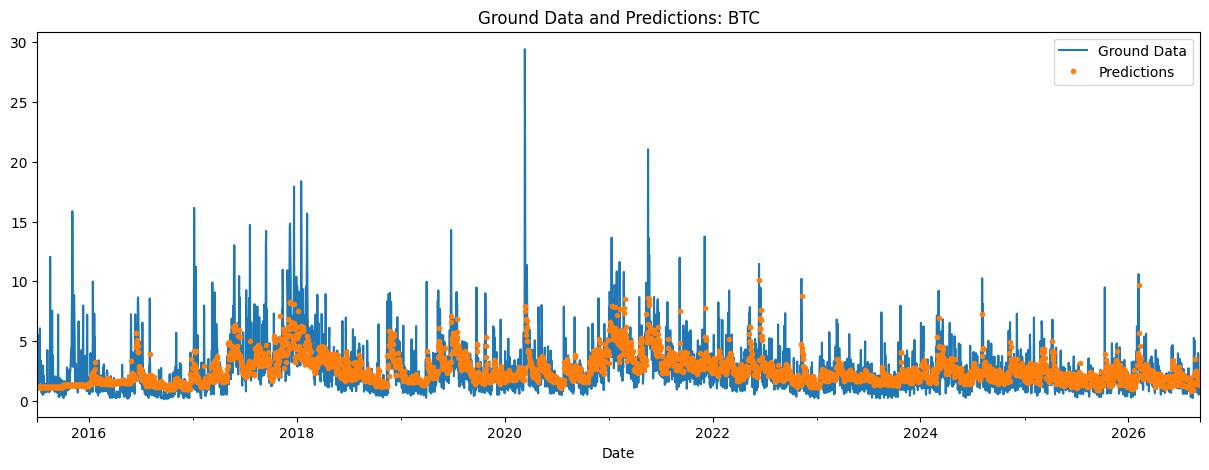

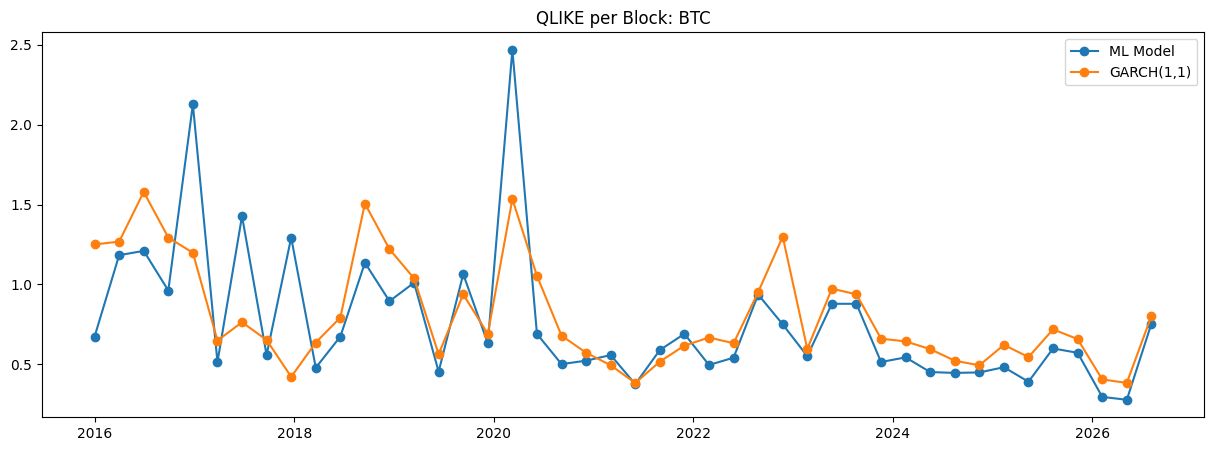

In [27]:
ml.plot_walk_forward(realised_vol, forecasts, results_per_block, asset)

# Hyperparameter Tuning
To improve the model can search through parameter space to find optimal combinations. To evaluate each combination would be computationally expensive. Will begin by only changing one parameter, and keeping the rest as defaults. From these results the best combinations can be tested.

Because interactions between the parameters are second-order effects, the best combination is likely to be the set of best parameters.

### Base Score
The first hyperparameter to change is base score. Rather than arbitrary choice of 0.5, the starting value can be informed by the mean of the previous volatility in the training set.

In [58]:
max_depth = [2, 3, 4]
learning_rate = [0.01, 0.03, 0.05]
min_child_weight = [1, 5, 10]

In [ ]:
child = ml.run_hyperparameter_sweep(asset_ohlcv, 'min_child_weight', min_child_weight)

child

GARCH(1,1) benchmark: qlike=0.8019, mse=676.1394, mae=10.8708


,qlike,mse,mae,qlike_median,qlike_std
min_child_weight,,,,,
1,0.8273,655.616,8.6014,0.6532,0.4882
5,0.8273,655.476,8.5760,0.6413,0.5148
10,0.8102,648.738,8.2996,0.6482,0.4688


In [ ]:
depth = ml.run_hyperparameter_sweep(asset_ohlcv, 'max_depth', max_depth)

depth

GARCH(1,1) benchmark: qlike=0.8019, mse=676.1394, mae=10.8708


,qlike,mse,mae,qlike_median,qlike_std
max_depth,,,,,
2,0.7874,641.7226,8.3742,0.5948,0.4773
3,0.8273,655.6160,8.6014,0.6532,0.4882
4,0.9199,660.0851,8.7881,0.7086,0.5622


In [ ]:
learning = ml.run_hyperparameter_sweep(asset_ohlcv, 'learning_rate', learning_rate)

learning

GARCH(1,1) benchmark: qlike=0.8019, mse=676.1394, mae=10.8708


,qlike,mse,mae,qlike_median,qlike_std
learning_rate,,,,,
0.01,0.8273,655.6160,8.6014,0.6532,0.4882
0.03,0.8305,652.8571,8.5884,0.6677,0.4908
0.05,0.8250,653.0380,8.5907,0.6593,0.4902


In [14]:
results_per_block, results_combined, forecasts = ml.run_walk_forward_comparison(asset_ohlcv,
                                                                                max_depth=2,
                                                                                learning_rate=0.03,
                                                                                min_child_weight=10)

In [15]:
df = pd.DataFrame(results_combined).T.round(4)
print(df)

                          qlike       mse      mae
GARCH(1,1)               0.8019  676.1394  10.8708
Naive (persistence)      1.9157  836.2759  10.4468
Naive (rolling avg)      1.0046  740.6088  11.4939
ML Model (Walk-Forward)  0.7443  636.8064   8.2635


Model   GARCH(1,1)  ML Model  Naive (persistence)  Naive (rolling avg)
mean        0.8053    0.7440               1.9147               1.0064
std         0.3283    0.3997               1.2873               0.4292
median      0.6644    0.5873               1.4601               0.9033
min         0.3831    0.2795               0.6744               0.4055
max         1.5791    2.4855               6.6931               2.0424


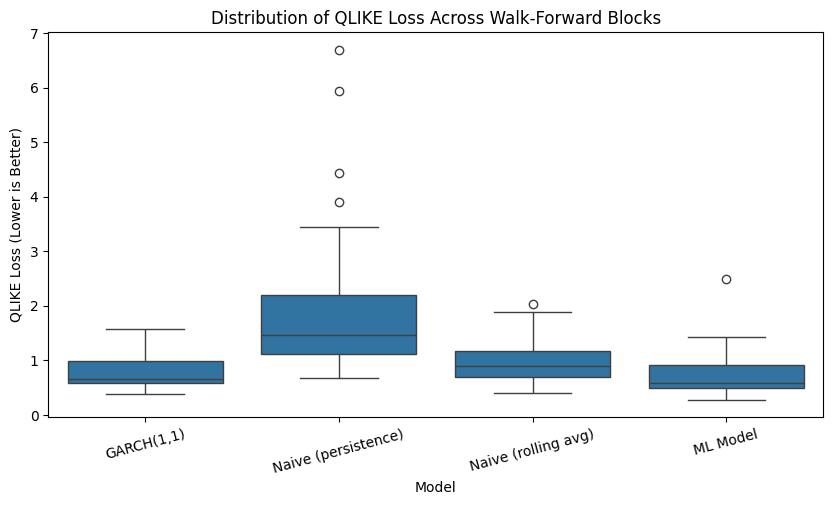

In [16]:
rows = []
for block, models in results_per_block.items():
    for model, metrics in models.items():
        row = {'Block': block, 'Model': model}
        row.update(metrics)
        rows.append(row)

df = pd.DataFrame(rows)

summary_stats = df.groupby('Model')[['qlike', 'mse', 'mae']].agg(['mean', 'std', 'median', 'min', 'max'])
summary_stats = summary_stats.round(4)

print(summary_stats['qlike'].T)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df.reset_index(), x='Model', y='qlike')
plt.title('Distribution of QLIKE Loss Across Walk-Forward Blocks')
plt.ylabel('QLIKE Loss (Lower is Better)')
plt.xticks(rotation=15)
plt.show()

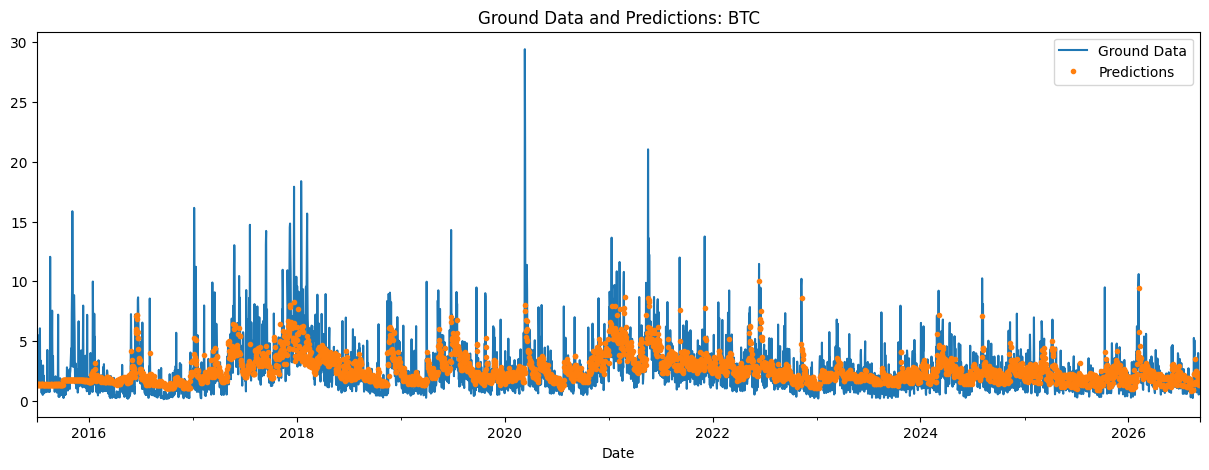

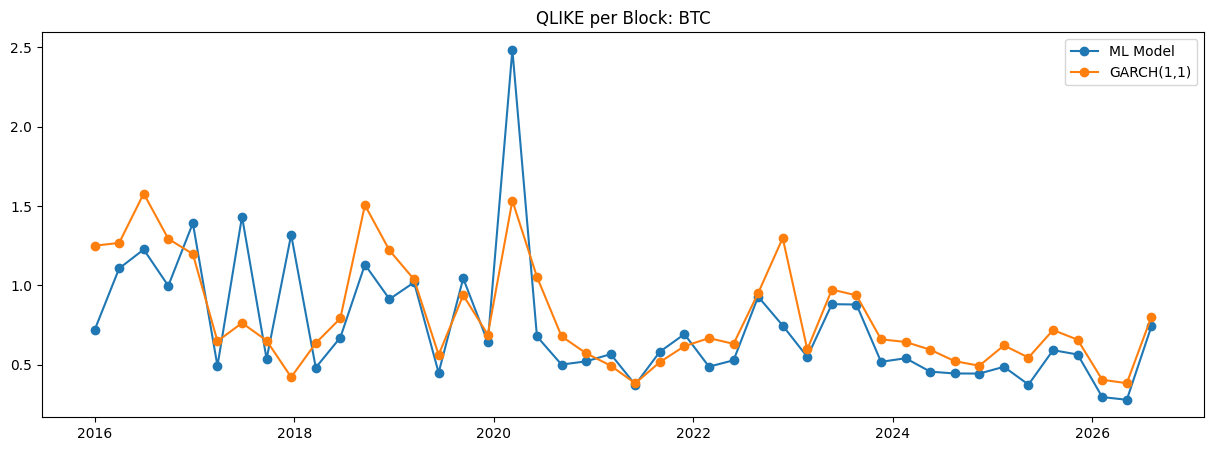

In [17]:
ml.plot_walk_forward(realised_vol, forecasts, results_per_block, asset)